# Quickstart — Hyperiax v3 in five minutes

Hyperiax lets you write tree message-passing algorithms in JAX. The whole user-facing API has four pieces:

| Piece | What it is |
|---|---|
| **`Topology`** | The static shape of the tree (who's whose parent). |
| **`Tree`** | `Topology` + a typed dict of per-node arrays. Immutable. Registered as a JAX pytree, so it rides through `jax.jit` / `jax.lax.scan` / `jax.grad` cleanly. |
| **`@hx.up` / `@hx.down`** | Decorators that turn a small Python function into a leaf→root or root→leaf sweep. |
| **Views** | Inside a sweep, you read data through `node.value`, `parent.value`, `children.value.mean(0)`. |

This notebook walks through all four. By the end you will have built a tree, run an up-sweep and a down-sweep, and verified that sweeps compose with `jax.jit`, `jax.lax.scan`, and `jax.grad`.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import hyperiax as hx

## 1. Build a topology

A `Topology` is a parent-pointer array plus a bunch of precomputed dispatch metadata. The only convention you need to remember:

- Nodes are stored in **BFS order**: the root is node `0`, and `parents[i] < i` for every other node.
- The root is its own parent (`parents[0] == 0`).

For perfectly symmetric trees there is a convenience constructor. We'll use a binary tree of height 3 — that's $1+2+4+8 = 15$ nodes.

In [2]:
topo = hx.symmetric_topology(height=3, degree=2)

print(topo)
print(f"  size:         {topo.size}")
print(f"  depth:        {topo.depth}")
print(f"  num leaves:   {int(topo.is_leaf.sum())}")
print(f"  equal_degree: {topo.equal_degree}")
print(f"  parents:      {topo.parents.tolist()}")

Topology(size=15, depth=3, equal_degree=True, max_degree=2)
  size:         15
  depth:        3
  num leaves:   8
  equal_degree: True
  parents:      [0, 0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]


A tiny matplotlib helper so we can see what's going on. Reuse this cell whenever you want to draw a tree.

> `topo.parents`, `topo.level_starts`, `topo.is_leaf`, ... are all `numpy` arrays — the topology lives in numpy-land so it can ride through `jax.jit` as static auxiliary data.

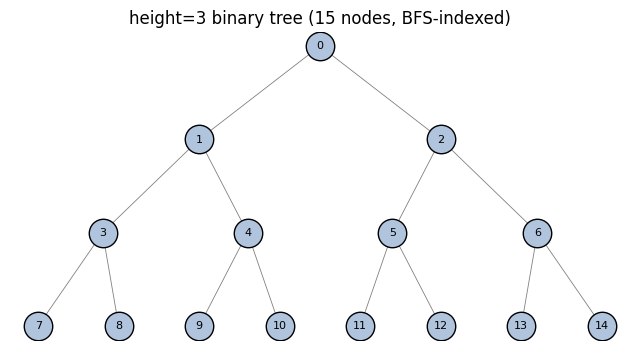

In [3]:
def plot_tree(topo, values=None, ax=None, title=None, cmap='viridis', vmin=None, vmax=None):
    """Top-down layered layout. Pass `values` (shape (N,)) to color nodes."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    pos = np.zeros((topo.size, 2))
    for d in range(topo.depth + 1):
        lo, hi = int(topo.level_starts[d]), int(topo.level_starts[d + 1])
        n = hi - lo
        if n == 1:
            pos[lo:hi, 0] = 0.5
        else:
            pos[lo:hi, 0] = np.linspace(0, 1, n + 2)[1:-1]
        pos[lo:hi, 1] = -d
    for i in range(1, topo.size):
        p = int(topo.parents[i])
        ax.plot([pos[p, 0], pos[i, 0]], [pos[p, 1], pos[i, 1]],
                'k-', lw=0.6, alpha=0.5, zorder=1)
    if values is None:
        ax.scatter(pos[:, 0], pos[:, 1], s=420, c='lightsteelblue',
                   edgecolor='k', zorder=3)
        for i in range(topo.size):
            ax.text(pos[i, 0], pos[i, 1], str(i), ha='center', va='center', fontsize=8)
    else:
        sc = ax.scatter(pos[:, 0], pos[:, 1], s=420, c=np.asarray(values),
                        edgecolor='k', cmap=cmap, vmin=vmin, vmax=vmax, zorder=3)
        plt.colorbar(sc, ax=ax, label='value', shrink=0.8)
    if title:
        ax.set_title(title)
    ax.set_axis_off()
    return ax

plot_tree(topo, title="height=3 binary tree (15 nodes, BFS-indexed)")
plt.show()

## 2. Declare a schema, allocate a `Tree`

A `Tree` is `Topology` + a `dict[str, jax.Array]` whose keys are fixed by a **schema**. You declare what fields exist up front:

```python
Tree.empty(topo, {'value': trailing_shape, ...})
```

Each field has a `(trailing_shape, dtype)` spec — `()` for a scalar field, `(2,)` for a 2-vector field, `(n, n)` for a matrix field, and so on. The leading axis is always the number of nodes; the schema only declares the trailing part.

> **Why declare it up front?** The schema is part of the pytree's static aux data. Adding fields later via `tree.update(...)` changes the pytree structure and invalidates `jit` caches keyed on the old shape. Inside a sweep pipeline you almost always know all your fields at construction time.

In [4]:
tree = hx.Tree.empty(topo, {'value': ()})
print(tree)
print("Initial values (zeros for every node):")
print(tree.value)

Tree(size=15, fields={value: ()})
Initial values (zeros for every node):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## 3. Seed the leaves

Trees are immutable. Every "mutator" — `set`, `set_at`, `update`, `drop` — returns a *new* `Tree`. This is what lets us put the whole computation inside `jax.jit` without the leaked-tracer headache of v2.

`set_at(mask_or_indices, field=values)` is the JAX-style scatter: equivalent to `arr.at[mask].set(values)` for the named field.

Leaves carry 0..7; inner nodes are still zero:
[0. 0. 0. 0. 0. 0. 0. 0. 1. 2. 3. 4. 5. 6. 7.]


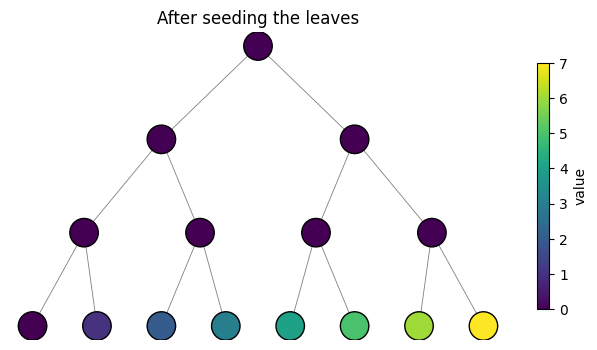

In [5]:
num_leaves = int(topo.is_leaf.sum())                # 8
leaf_obs = jnp.arange(num_leaves, dtype=jnp.float32)

tree = tree.set_at(topo.is_leaf, value=leaf_obs)
print("Leaves carry 0..7; inner nodes are still zero:")
print(tree.value)

plot_tree(topo, tree.value, title="After seeding the leaves")
plt.show()

## 4. An up-sweep: propagate information leaf → root

An up-sweep visits every level from the leaves toward the root. At each non-leaf node, your function receives:

- **`node`** — the node's own fields. Each attribute has shape `(*trailing,)` (one node at a time, courtesy of `jax.vmap` inside the dispatcher).
- **`children`** — the children of this node. For an equal-degree tree, `children.value` is a real JAX array of shape `(k, *trailing)` — slice it, multiply it, sum it like any other array. For unequal-degree trees, the same expression works through a `ChildrenAxis` proxy that dispatches reductions to `jax.ops.segment_*`.
- **`params`** — whatever you pass via `sweep(tree, params=...)` (a dict, an array, anything pytree-shaped).

Your function returns a `dict` whose keys exactly match the `writes=` argument. Each value must have shape `(*trailing,)` — one record per node, no need to keep a per-parent batch axis.

We'll compute the simplest message possible: each non-leaf node = mean of its children.

In [6]:
@hx.up(reads_children=('value',), writes=('value',))
def average_children(node, children, params):
    return {'value': children.value.mean(0)}

tree_after_up = average_children(tree)

print("Root value after up-sweep: ", float(tree_after_up.value[0]))
print("Mean of the leaves:         ", float(leaf_obs.mean()))
print("All node values:\n", np.asarray(tree_after_up.value))

Root value after up-sweep:  3.5
Mean of the leaves:          3.5
All node values:
 [3.5 1.5 5.5 0.5 2.5 4.5 6.5 0.  1.  2.  3.  4.  5.  6.  7. ]


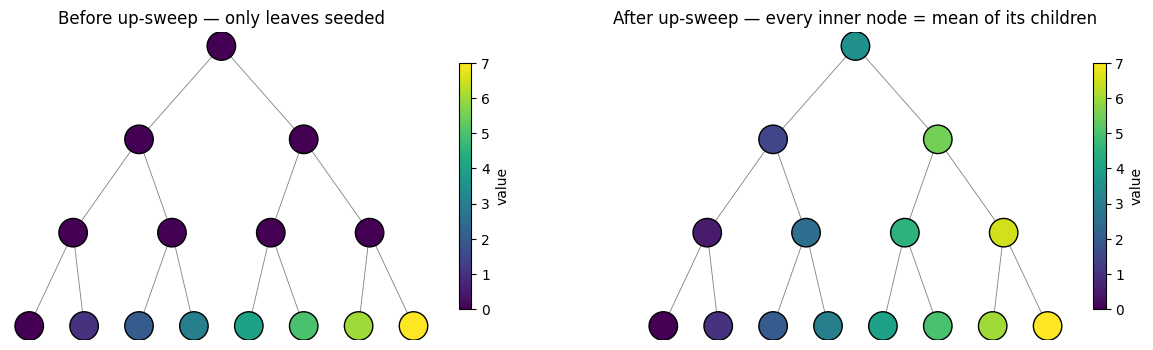

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
vmin, vmax = 0.0, float(num_leaves - 1)
plot_tree(topo, tree.value, ax=axes[0],
          title="Before up-sweep — only leaves seeded", vmin=vmin, vmax=vmax)
plot_tree(topo, tree_after_up.value, ax=axes[1],
          title="After up-sweep — every inner node = mean of its children",
          vmin=vmin, vmax=vmax)
plt.show()

Two things to notice:

1. `tree` itself is unchanged. `average_children` returned a brand-new `Tree`. This is what lets `jax.jit` see the call as a pure function.
2. We only declared `reads_children=('value',)`. We did **not** declare `reads=` on the node itself, because the function doesn't read it. If you forget to declare a field that you actually read, you'll get a clear `AttributeError` pointing at the missing entry — the dispatcher only hands you the fields you asked for.

## 5. A down-sweep: propagate information root → leaf

The mirror image. Your function receives `(node, parent, params)`; for each non-root node, `parent.value` is a `(*trailing,)` view of that node's parent (already updated by the sweep when it visits the level above).

The **root is not visited** (it has no parent), so you must seed it manually before calling the sweep.

Here we use two fields: a `delta` we'll set per node, and a `value` whose root we'll seed. The sweep then propagates `value = parent.value + delta` down the tree.

Root (kept):        10.0
Children of root:   [10.5 11. ]
All values:
 [10.  10.5 11.  12.  12.5 13.5 14.  15.5 16.  17.  17.5 19.  19.5 20.5
 21. ]


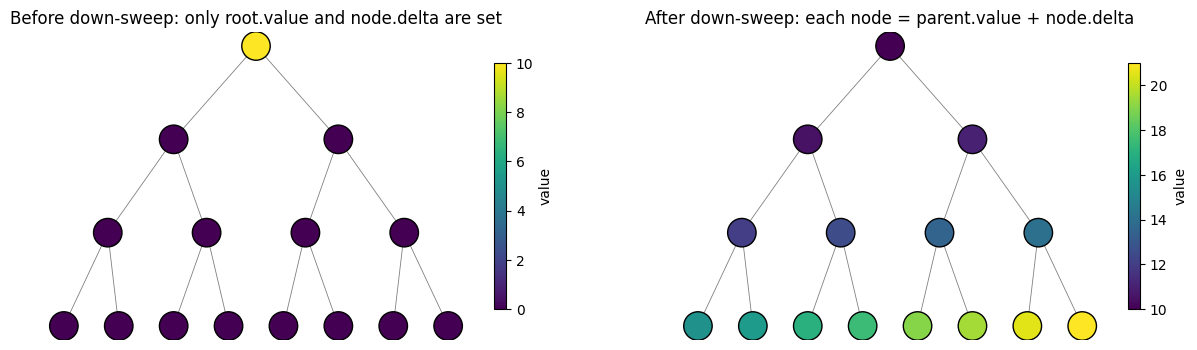

In [8]:
tree_down = hx.Tree.empty(topo, {'value': (), 'delta': ()})

tree_down = tree_down.set_at(topo.is_root, value=jnp.array([10.0]))
tree_down = tree_down.set(delta=jnp.arange(topo.size, dtype=jnp.float32) * 0.5)

@hx.down(reads=('delta',), reads_parent=('value',), writes=('value',))
def propagate(node, parent, params):
    return {'value': parent.value + node.delta}

tree_down_done = propagate(tree_down)

print("Root (kept):       ", float(tree_down_done.value[0]))
print("Children of root:  ", np.asarray(tree_down_done.value[1:3]))
print("All values:\n", np.asarray(tree_down_done.value))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_tree(topo, tree_down.value, ax=axes[0],
          title="Before down-sweep: only root.value and node.delta are set")
plot_tree(topo, tree_down_done.value, ax=axes[1],
          title="After down-sweep: each node = parent.value + node.delta")
plt.show()

## 6. Sweeps compose with `jit`, `scan`, `grad`

This is the headline feature of v3. A `Tree` is a JAX pytree (data values are leaves; topology + schema are static aux data), and every sweep is a pure `Tree → Tree`. That means **all of JAX's transformations work directly**.

### 6a. `jax.jit`

Wrap the sweep in `jax.jit`. The first call compiles; subsequent calls on trees with the same structure hit the cache.

In [9]:
@jax.jit
def one_step(t):
    return average_children(t)

result = one_step(tree)
print("JIT result matches eager:",
      bool(jnp.allclose(result.value, tree_after_up.value)))

# Second call hits the cache — no recompile.
_ = one_step(tree)
print("Two calls, one compile.")

JIT result matches eager: True
Two calls, one compile.


### 6b. `jax.lax.scan`

Iterate the same sweep `N` times in a single compiled loop. The body traces once, no Python overhead per iteration.

In [10]:
def body(t, _):
    return average_children(t), None

final, _ = jax.lax.scan(body, tree, xs=None, length=10)
print("After 10 sweeps the tree has converged (leaves don't change):")
print("  root after 10 sweeps:", float(final.value[0]))
print("  root after 1 sweep:  ", float(tree_after_up.value[0]))

After 10 sweeps the tree has converged (leaves don't change):
  root after 10 sweeps: 3.5
  root after 1 sweep:   3.5


### 6c. `jax.grad`

Differentiate end-to-end. Here we treat the leaf observations as the inputs and the root value as the output. With a mean sweep on a height-3 binary tree, each leaf contributes $1/8$ to the root.

In [11]:
def root_from_leaves(leaf_vals):
    t = hx.Tree.empty(topo, {'value': ()})
    t = t.set_at(topo.is_leaf, value=leaf_vals)
    return average_children(t).value[0]

grads = jax.grad(root_from_leaves)(leaf_obs)
print("d(root) / d(leaves) =", np.asarray(grads))
print("expected: 1/8 for each of the 8 leaves =", 1.0 / num_leaves)

d(root) / d(leaves) = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
expected: 1/8 for each of the 8 leaves = 0.125


## Recap & next steps

You've now seen the entire core API:

- `hx.symmetric_topology(height, degree)` (and `hx.from_parents(parents)` for arbitrary topologies)
- `hx.Tree.empty(topo, schema)`, `tree.set(...)`, `tree.set_at(mask, ...)`
- `tree.value` for field access (or `tree['value']` when the field name is a dynamic string or collides with a reserved name like `size`)
- `@hx.up(reads_children=, writes=)` with `(node, children, params) -> dict`
- `@hx.down(reads_parent=, writes=)` with `(node, parent, params) -> dict`
- `node.value`, `children.value.mean(0)`, `parent.value` inside a sweep
- Sweeps compose with `jax.jit`, `jax.lax.scan`, `jax.grad` directly

Where to go next:

- **`02_writing_sweeps.ipynb`** — go deeper: equal vs unequal degree trees, the `reads / reads_children / reads_parent / writes` declaration model, custom reductions on the children axis, common patterns (subtree sizes, max depth, weighted means, belief propagation).
- **`03_phylo_mean.ipynb`** — read a real Newick tree, run the `phylo_mean` prebuilt on it.
- **`04_phylo_bayesian.ipynb`** — upgrade the point estimate to a full Bayesian posterior over ancestral states.